# Studi Kasus Mahasiswa 1 Data cleaning

In [1]:
import kagglehub
import pandas as pd

/home/pratama/dev-python/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Downloading Dataset

In [ ]:
df = pd.read_csv("../dataset/creditcard.csv")
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Data Ingestion

In [3]:
# cek missing values
print("\nMissing Values:\n", df.isnull().sum())

# cek duplikasi
print("\nDuplicate Rows:", df.duplicated().sum())

# hapus duplikat kalau ada
df = df.drop_duplicates()

print("\nShape setelah drop duplicate:", df.shape)


Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicate Rows: 1081

Shape setelah drop duplicate: (283726, 31)


# Exploratory Data Analysis (EDA)

Class
0    283253
1       473
Name: count, dtype: int64


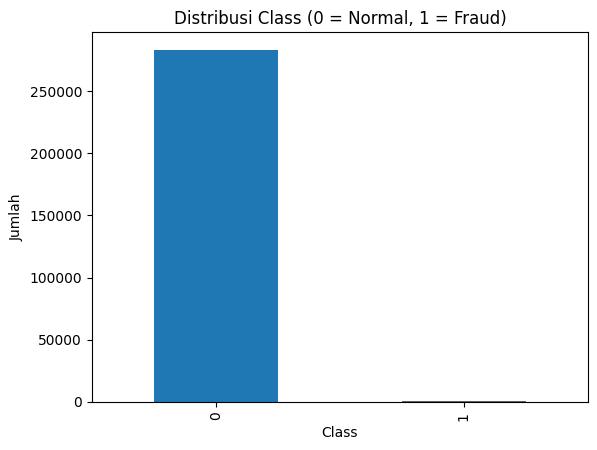

In [ ]:
import matplotlib.pyplot as plt

class_counts = df['Class'].value_counts()

print(class_counts)

plt.figure()
class_counts.plot(kind='bar')
plt.title("Distribusi Class (0 = Normal, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Jumlah")
plt.show()

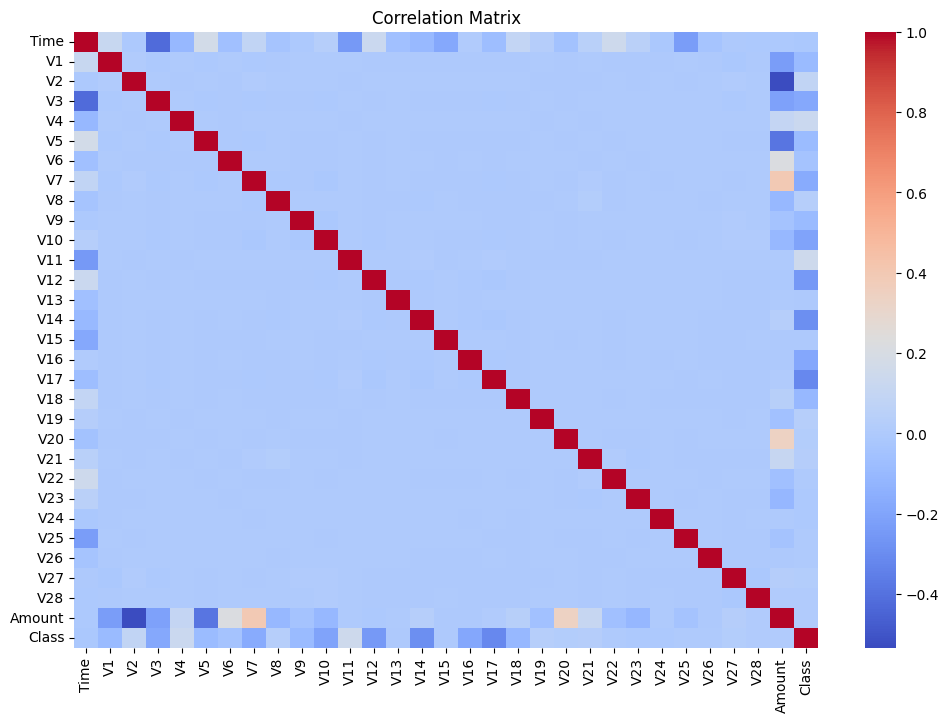

In [5]:
#  Korelasi Fitur
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Scientific Preprocessing 

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# drop original
df = df.drop(['Amount', 'Time'], axis=1)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244200,-1.996823
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342584,-1.996823
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.158900,-1.996802
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.139886,-1.996802
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073813,-1.996781


# Data Partitioning (Stratified)

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", y_train.value_counts())
print("Test:", y_test.value_counts())



Train: Class
0    226602
1       378
Name: count, dtype: int64
Test: Class
0    56651
1       95
Name: count, dtype: int64


# Scientific Balancing

In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_res).value_counts())

Before SMOTE: Class
0    226602
1       378
Name: count, dtype: int64
After SMOTE: Class
0    226602
1    226602
Name: count, dtype: int64


# Visualisasi hasil balancing

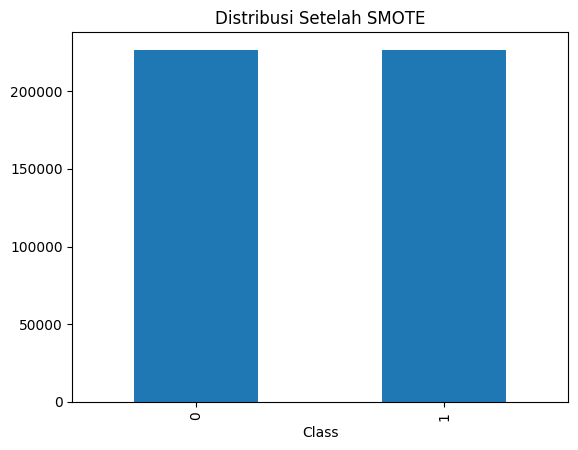

In [9]:
plt.figure()
pd.Series(y_train_res).value_counts().plot(kind='bar')
plt.title("Distribusi Setelah SMOTE")
plt.show()

# Studi kasus  mahasiswa 2

## Architecture Design

In [ ]:
from sklearn.svm import SVC

# model awal
# svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True)
svm_model = SVC(random_state=0)
svm_model.fit(X_train_res, y_train_res)

## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    # Kernel mahal
    'kernel': ['rbf']
    # Kernel
}

# grid = GridSearchCV(SVC(class_weight='balanced', probability=True),
#                     param_grid,
#                     scoring='f1',
#                     cv=3,
#                     n_jobs=-1)

grid = GridSearchCV(SVC(random_state = 0),
                    param_grid,
                    scoring='f1',
                    cv=3,
                    # Jumlah CPU core yang dipakai untuk proses pararell
                    # -1 artinya semua thread dipakai
                    n_jobs=-1)


grid.fit(X_train_res, y_train_res)

best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

/home/pratama/dev-python/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


## Performance Audit

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

In [ ]:
# Confussion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Explainable AI(Menggunakan SHAP)

In [ ]:
import shap

# ambil sample biar gak berat
X_sample = X_train_res.sample(100, random_state=42)

explainer = shap.KernelExplainer(best_model.predict_proba, X_sample)

shap_values = explainer.shap_values(X_test.iloc[:50])

shap.summary_plot(shap_values[1], X_test.iloc[:50])

## Policy Simulation (What-if)

In [ ]:
import numpy as np

sample = X_test.iloc[0].copy()

# prediksi awal
print("Original:", best_model.predict([sample]))

# simulasi: transaksi besar banget
sample['scaled_amount'] = sample['scaled_amount'] * 5

print("After Increase Amount:", best_model.predict([sample]))

In [ ]:
# Simulasi multi skenario
for factor in [1, 2, 5, 10]:
    temp = X_test.iloc[0].copy()
    temp['scaled_amount'] *= factor

    pred = best_model.predict([temp])[0]
    print(f"Factor {factor}: {pred}")